In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})

**Computation of the price of a European call option using the Black-Scholes closed-form formula.**  
Notations :
- S : Spot price
- K : Strike price
- T : Exercise date
- r : Risk-free interest rate
- volatility ($\sigma$) : Volatility

In [69]:
def black_scholes_call_price(S,K,T,r,volatility) :
    d1 = (np.log(S/K) + (r+(volatility**2)/2)*T)/(volatility*np.sqrt(T))
    d2 = d1 - volatility*np.sqrt(T)
    N_d1 = norm.cdf(d1)
    N_d2 = norm.cdf(d2)
    return S*N_d1 - K*np.exp(-r*T)*N_d2

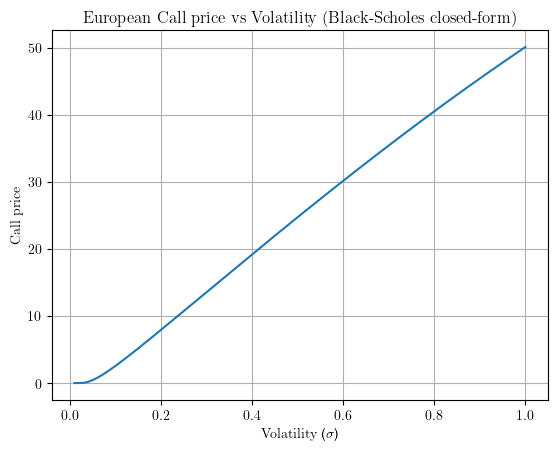

In [71]:
volatilities = np.linspace(0.01,1,400)
prices = [black_scholes_call_price(S=100,K=120,T=2,r=0.05,volatility=s) for s in volatilities]
plt.plot(volatilities,prices)
plt.xlabel(r"\textrm{Volatility} ($\sigma$)") 
plt.ylabel(r"\textrm{Call price}")
plt.title(r"\textrm{European Call price vs Volatility (Black-Scholes closed-form)}")
plt.grid(True)
plt.show()

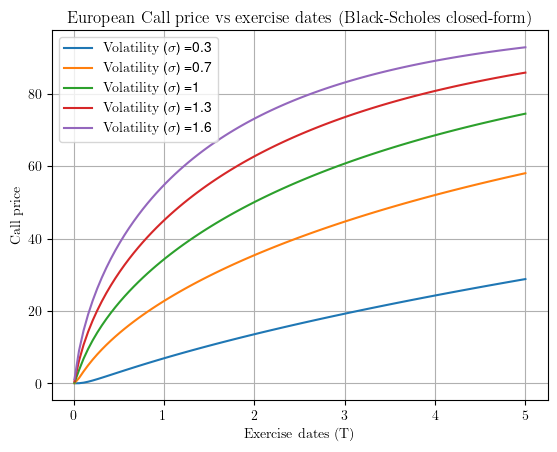

In [75]:
exercise_dates = np.linspace(0.01,5,100)
volatilities=[0.3,0.7,1,1.3,1.6]
for s in volatilities :
    plt.plot(exercise_dates,[black_scholes_call_price(S=100,K=120,T=t,r=0.05,volatility=s) for t in exercise_dates], label = rf"\textrm{{Volatility}} ($\sigma$) ={s}")

plt.xlabel(r"\textrm{Exercise dates (T)}")
plt.ylabel(r"\textrm{Call price}")
plt.legend()
plt.title(r"\textrm{European Call price vs exercise dates (Black-Scholes closed-form)}")
plt.grid(True)
plt.show()

**Computation of the price of a European call option + convergence of the binomial price to the BS price with the binomial tree method.**  
Notations :  
- N : Number of steps
- dt : Length of the step
- u : Up movement factor (e.g., 1.1 for a 10% increase)
- d : Down movement factor
- p : Probability of an up movement
- discount : Used to compute the present value of future cash flows under continuous compounding

In [78]:
def binomial_call_price(S, K, T, r, sigma, N):
    dt = T / N 
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    discount = np.exp(-r * dt)
    
    prices = np.array([S * (u**j) * (d**(N - j)) for j in range(N + 1)])
    option_values = np.maximum(prices - K, 0)
    
    for i in range(N - 1, -1, -1):
        option_values = discount * (p * option_values[1:] + (1 - p) * option_values[:-1])
    
    return option_values[0]

In [80]:
S = 100
K = 100
T = 1.0
r = 0.05
volatility = 0.2

In [82]:
#Comparison between Black-Scholes and Binomial Tree Option Prices
bs_price = black_scholes_call_price(S, K, T, r, volatility)
bin_price = binomial_call_price(S, K, T, r, volatility, N=1000)

print(f"Black-Scholes Price (closed form) : {bs_price:.4f}")
print(f"Binomial Price (N=100) : {bin_price:.4f}")

Black-Scholes Price (closed form) : 10.4506
Binomial Price (N=100) : 10.4486


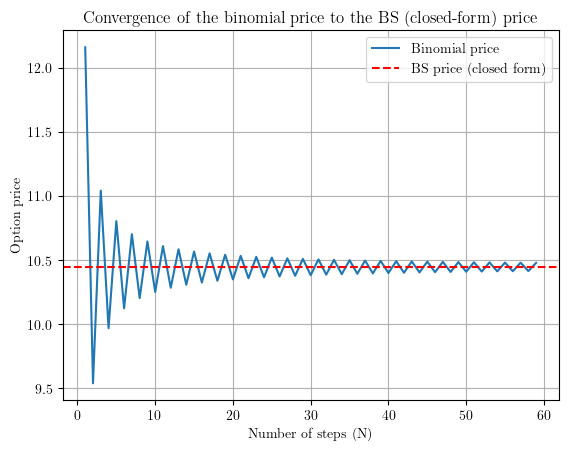

In [86]:
N_values = range(1,60)
binomial_prices = [binomial_call_price(S,K,T,r,volatility,N) for N in N_values]
plt.plot(N_values, binomial_prices, label=r"\textrm{Binomial price}")
plt.axhline(y=bs_price, color='r', linestyle='--', label=r"\textrm{BS price (closed form)}")
plt.xlabel(r"\textrm{Number of steps (N)}")
plt.ylabel(r"\textrm{Option price}")
plt.title(r"\textrm{Convergence of the binomial price to the BS (closed-form) price }")
plt.legend()
plt.grid(True)
plt.show()

**Computation of the price of a European call option + convergence of the binomial price to the BS price with QuantLib.**  

BS Price (closed form) : 10.4506


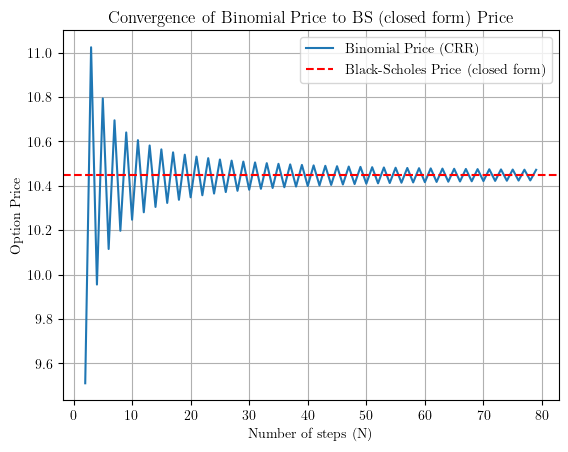

In [91]:
import QuantLib as ql
import matplotlib.pyplot as plt

spot_price = 100
strike_price = 100
T = 1.0
r = 0.05
volatility = 0.2

calendar = ql.TARGET()
today = ql.Date.todaysDate()
ql.Settings.instance().evaluationDate = today
maturity_date = today + int(365*T)

spot_handle = ql.QuoteHandle(ql.SimpleQuote(spot_price))

flat_ts = ql.YieldTermStructureHandle(ql.FlatForward(today,
                                                     r,
                                                     ql.Actual365Fixed()))

flat_vol_ts = ql.BlackVolTermStructureHandle(
    ql.BlackConstantVol(today,
                        calendar,
                        volatility,
                        ql.Actual365Fixed()))

bsm_process = ql.BlackScholesMertonProcess(spot_handle,
                                           ql.YieldTermStructureHandle(ql.FlatForward(today,0.0,ql.Actual365Fixed())),
                                           flat_ts,
                                           flat_vol_ts)

payoff = ql.PlainVanillaPayoff(ql.Option.Call, strike_price)
exercise = ql.EuropeanExercise(maturity_date)
european_option = ql.VanillaOption(payoff, exercise)

bs_engine = ql.AnalyticEuropeanEngine(bsm_process)
european_option.setPricingEngine(bs_engine)
bs_price = european_option.NPV()
print(f"BS Price (closed form) : {bs_price:.4f}")

N_values = list(range(2,80))
binomial_prices=[]

for N in N_values :
    binomial_engine = ql.BinomialVanillaEngine(bsm_process, "crr", N)
    european_option.setPricingEngine(binomial_engine)
    price = european_option.NPV()
    binomial_prices.append(price)

plt.plot(N_values, binomial_prices, label=r"\textrm{Binomial Price (CRR)}")
plt.axhline(y=bs_price, color = 'r', linestyle='--', label = r"\textrm{Black-Scholes Price (closed form)}")
plt.xlabel(r"\textrm{Number of steps (N)}")
plt.ylabel(r"\textrm{Option Price}")
plt.title(r"\textrm{Convergence of Binomial Price to BS (closed form) Price")
plt.legend()
plt.grid()
plt.show()






**Computation of the price of a European call option using Monte-Carlo simulation with QuantLib.** 

In [94]:
import QuantLib as ql
import numpy as np


spot_price = 100
strike_price = 100
T = 1.0
r = 0.05
volatility = 0.2
steps=1
num_paths = 1000000

calendar = ql.TARGET()
today = ql.Date.todaysDate()
ql.Settings.instance().evaluationDate = today
maturity_date = today + int(365*T)


spot_handle = ql.QuoteHandle(ql.SimpleQuote(spot_price))
yield_curve = ql.YieldTermStructureHandle(
    ql.FlatForward(today, r, ql.Actual365Fixed())
)
dividend_curve = ql.YieldTermStructureHandle(
    ql.FlatForward(today, 0.0, ql.Actual365Fixed())  # pas de dividende
)
vol_curve = ql.BlackVolTermStructureHandle(
    ql.BlackConstantVol(today, calendar, volatility, ql.Actual365Fixed())
)

bsm_process = ql.BlackScholesMertonProcess(spot_handle, dividend_curve, yield_curve, vol_curve)

payoff = ql.PlainVanillaPayoff(ql.Option.Call, strike_price)
exercise = ql.EuropeanExercise(maturity_date)
option = ql.VanillaOption(payoff, exercise)

mc_engine = ql.MCEuropeanEngine(
    bsm_process,
    "pseudorandom",
    timeSteps=steps,
    requiredSamples=num_paths,
    seed=42
)
option.setPricingEngine(mc_engine)

mc_price = option.NPV()
print(f"Price with Monte Carlo : {mc_price:.4f}")

#Comparison with the BS (closed form) price
bs_engine = ql.AnalyticEuropeanEngine(bsm_process)
option.setPricingEngine(bs_engine)
bs_price = option.NPV()
print(f"Price with Black-Scholes (closed form) : {bs_price:.4f}")





Price with Monte Carlo : 10.4515
Price with Black-Scholes (closed form) : 10.4506


**Application to the case of a real underlying asset**

[*********************100%***********************]  1 of 1 completed

Option type : European call option
Stock price : $6043.350
Strike price : $6043.350
Maturity : 1 years
Risk-free rate : 0.03
Volatility : 0.198
Number of steps : 1000
--- --- --- --- --- ---
BS (closed form)      : 564.2106
Binomial tree    : 564.0920
QuantLib BS (closed form)  : 564.2106


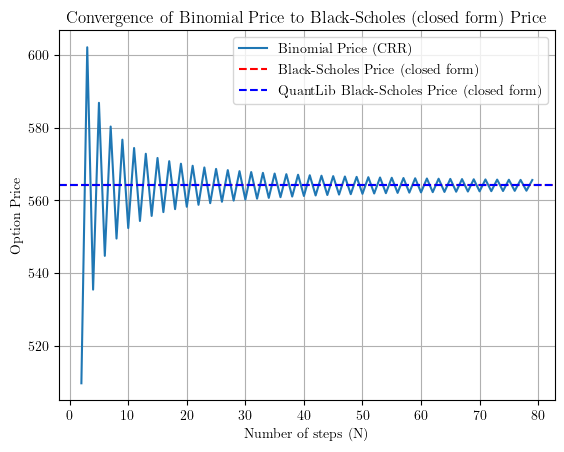

In [51]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import QuantLib as ql
from scipy.stats import norm

ticker = "^GSPC"
data = yf.download(ticker,period="1y",auto_adjust=True)
S = data["Close"].iloc[-1].iloc[0]
K = S
T = 1
r = 0.03
volatility = (data["Close"].pct_change().std() * np.sqrt(252)).iloc[0]
N = 1000

calendar = ql.TARGET()
today = ql.Date.todaysDate()
ql.Settings.instance().evaluationDate = today
maturity_date = today + int(365*T)

spot_handle = ql.QuoteHandle(ql.SimpleQuote(S))

flat_ts = ql.YieldTermStructureHandle(ql.FlatForward(today,
                                                     r,
                                                     ql.Actual365Fixed()))

flat_vol_ts = ql.BlackVolTermStructureHandle(
    ql.BlackConstantVol(today,
                        calendar,
                        volatility,
                        ql.Actual365Fixed()))

bsm_process = ql.BlackScholesMertonProcess(spot_handle,
                                           ql.YieldTermStructureHandle(ql.FlatForward(today,0.0,ql.Actual365Fixed())),
                                           flat_ts,
                                           flat_vol_ts)

payoff = ql.PlainVanillaPayoff(ql.Option.Call, K)
exercise = ql.EuropeanExercise(maturity_date)
european_option = ql.VanillaOption(payoff, exercise)

bs_engine = ql.AnalyticEuropeanEngine(bsm_process)
european_option.setPricingEngine(bs_engine)



bs_price = black_scholes_call_price(S,K,T,r,volatility)
binomial_tree_price = binomial_call_price(S, K, T, r, volatility, N)
ql_bs_price = european_option.NPV()

print("Option type : European call option")
print(f"Stock price : ${S:.3f}")
print(f"Strike price : ${K:.3f}")
print(f"Maturity : {T} years")
print(f"Risk-free rate : {r}")
print(f"Volatility : {volatility:.3f}")
print(f"Number of steps : {N}")
print("--- --- --- --- --- ---")


print(f"BS (closed form)      : {bs_price:.4f}")
print(f"Binomial tree    : {binomial_tree_price:.4f}")
print(f"QuantLib BS (closed form)  : {ql_bs_price:.4f}")


N_values = list(range(2,80))
binomial_prices=[]

for N in N_values :
    binomial_engine = ql.BinomialVanillaEngine(bsm_process, "crr", N)
    european_option.setPricingEngine(binomial_engine)
    price = european_option.NPV()
    binomial_prices.append(price)

plt.plot(N_values, binomial_prices, label=r"\textrm{Binomial Price (CRR)}")
plt.axhline(y=bs_price, color = 'r', linestyle='--', label = r"\textrm{Black-Scholes Price (closed form)}")
plt.axhline(y=ql_bs_price, color = 'b', linestyle='--', label = r"\textrm{QuantLib Black-Scholes Price (closed form)}")
plt.xlabel(r"\textrm{Number of steps (N)}")
plt.ylabel(r"\textrm{Option Price}")
plt.title(r"\textrm{Convergence of Binomial Price to Black-Scholes (closed form) Price")
plt.legend()
plt.grid()
plt.show()



